# __Part 0__: Preliminary Installations
pyRDDLGym can be installed in several way, the most simple is to just pip install it:

In [ ]:
!pip install pyRDDLGym
!pip install rddlrepository

If there was a message to restart the runtime, remember to do so!

# __Part 1__: pyRDDLGym Introduction


## Imports!
- The most basic class is the environment class. It allows for instantiation of gym environments from RDDL. We use a factory method "make" just like in regular gym.
- The second class we need to know about is _rddlrepository_. This is the database of all the official RDDL problems. We can use it directly if we want to query about a problem, but pyRDDLGym does that for us when we just want to play with one of the exisiting problems.

In [3]:
import pyRDDLGym
import rddlrepository
from IPython.display import Image # for displaying gifs in colab

We will also set at this point the working directory for this notebook:

In [4]:
base_path = '/content/'

## Listing Built-in Environments

the pyRDDLGym eco-system comes with several (a lot) of problems already implemented, from past IPCs, standard OpenAI Gym converted to RDDL environment to community contributed domains. The official archive for RDDL environment is the `rddlrepositry` package. when pyRDDLGym is prompt to initialize an environment, it will automatically quary rddlrpository.

let's see how to access `rddlrepository` directly:

In [5]:
from rddlrepository.core.manager import RDDLRepoManager
manager = RDDLRepoManager(rebuild=True)

The `manager` object is the access point to the archive. Throught the manager every environment can be acessed, and retrieved. To list all the built-in environment the list_problems is used"

In [ ]:
manager.list_problems()

Let's query a specific example, the `MountainCar_Continuous_gym`. This is a conversion from the standard Gym environemnt `MountainCar` to RDDL. This one specifically is the continuous actions versions, and thus the name. Let's see what we get when we ask to retreive it

In [ ]:
problem_info = manager.get_problem("MountainCar_Continuous_gym")
print(problem_info)

Aside from the description, we get the path to the RDDL files (which the manager we use if we ask for a domain/instance). We also see the avialbe instances, in this case there is only one, the standard signel valley instance.
Additionally, we get a vizualizer object - some instances come with dedicated visuallzers that can be retreived, if a visuallizer is not supplied, the standard built it visuallizers of pyRDDLGym are avialable.

For MountainCar there is another version avialable in rddlrepository, the one used in the 2023 IPC:

In [ ]:
problem_info = manager.get_problem("MountainCar_ippc2023")
print(problem_info)

As the two are based on the same environment (the same RDDL domain file), they also share the visuallizer, but this one has 5 instances (varing amount of vallies and hills), and of course, located in a different place in the archive.

## Initializing an Environment

An environment can be instantiated using _rddlrepository_ manually, but we can also just tell _pyRDDLGym_ the name of the problem and it will look it up for us. Let's try it with the known 'MountainCar' problem. We wlso need an instance, we will choose instance 0:

In [ ]:
ENV = 'MountainCar_Continuous_gym'
myEnv = pyRDDLGym.make(ENV, 0)

All of pyRDDLGym environments by default use the ChartVisualizer. Some examples have a dedicated custom visualizer, when pyRDDLGym is asked for a problem _rddlrepository_, it also loads its visualizer if it exists, otherwise the ChartVisualizer is used.

The ChartVisuzlier will visualize every state-fluent in the rddl instance, it supports both Continuous and Discrete variables.

Because Colab do not allow for external displays we will make use here of the MovieGenerator, and instead of redering the visuals to the screen we will generate a gif.

The function set_visualizer() allows for setting the specific viz and additional things like the movie generator.

Actually, pyRDDLGym comes with 3 types of built-in visualizer, the ChartVisualizer, HeatmapVisualizer, and TextVisualizer.

In [18]:
chart_type="chart" # @param ["text", "heatmap", "chart"]

In [19]:
from pyRDDLGym.core.visualizer.movie import MovieGenerator
MovieGen = MovieGenerator(base_path, ENV, 200)
myEnv.set_visualizer(chart_type, movie_gen=MovieGen, movie_per_episode=True)
gif_name = ENV+'_'+chart_type

## Initializing a Simple Built-in Agent

pyRDDLGym comes out of the box with simple agents (and a sophisticaed one, more on it later), we need an agent to create a simple interaction. We will use the Random agent - simple sampling from the gym.action_space

In [20]:
from pyRDDLGym.core.policy import RandomAgent
agent = RandomAgent(action_space=myEnv.action_space,
                        num_actions=myEnv.max_allowed_actions,
                        seed=42)

Note that RDDL environment are concurrent by nature, thus our agent needs to know how many action he can apply at a given time step. That property of the RDDL is accessible through the `myEnv.max_allowed_actions` property.

## The Interaction Loop.

Now we are ready to run a simple random agent in an example environment!
Note, that the following interaction loop is a standard Gym loop. There is no indication that the environment or it's properties came from somewhere else, completly standard.

The only new thing is the use of pyRDDLGym movie generator after the loop.

In [ ]:
total_reward = 0
state, _ = myEnv.reset()
for step in range(myEnv.horizon):
    myEnv.render(to_display=False)
    action = agent.sample_action()
    next_state, reward, done, info, _ = myEnv.step(action)
    total_reward += reward
    print()
    print(f'step       = {step}')
    print(f'state      = {state}')
    print(f'action     = {action}')
    print(f'next state = {next_state}')
    print(f'reward     = {reward}')
    state = next_state
    if done:
        break
print(f'episode ended with reward {total_reward}')

myEnv.close()
MovieGen.save_animation(gif_name)
Image(open(base_path+gif_name+'.gif','rb').read())

## Specifying Custom Visualizer

Now we are going to update the visualizer of the environment manually to the custom one of the mountain car problem.

In order to do so we need to pull the information of the problem from _rddlrepository_:

In [22]:
from rddlrepository.core.manager import RDDLRepoManager
manager = RDDLRepoManager()
ProblemInfo = manager.get_problem(ENV)

The ```ProblemInfo``` object contains all the information about the problem, e.g., the path to the RDDL files, path to the visualizer class, etc.

All we need to do is to ask it for the visualizer via the ```get_visualizer()``` method, and set it in the environment via the ```set_visualizer``` method:

In [23]:
myEnv.set_visualizer(ProblemInfo.get_visualizer(), movie_gen=MovieGen, movie_per_episode=True)
gif_name =  ENV+'_builtinviz'

Now, run the interaction loop again and witness the magic.

# __Part 2__: Multi-Reservoir Control - From Model to a Working Gym Environment

## Introduction

Reservoir control plays a crucial role in managing water resources, optimizing energy production, and ensuring sustainable development. By implementing effective control strategies, we can enhance the efficiency and reliability of reservoir operations, leading to better water supply management, flood control, and power generation.

In this tutorial, we will present the fundamental concepts involved in developing a reservoir control model. We will develop a basic version of the mathematical equations that govern reservoir behavior and understand how to pose them as a RDDL domain. Then we will see how to lift up the problem as easily create a multi-reservoir problem. Finally we will use the built-in model-based planner coming with pyRDDLGym to obtain a policy for the problem.


## Part 1 - Modeling

In this part we will model a single reservoir and generalize to a network of reservoirs. Later we will translate this model into RDDL.


### The Single Reservoir Model

We will begin by looking at a single reservoir model

![Reservior](https://github.com/pyrddlgym-project/data/blob/main/Tutorial/ICAPS2023/reservoir.png?raw=true)


### The Physical Model
The reservoir is a basically a tank of water. For simplicity the cross sectional area of the tank is taken to be 1.
- The tank is characterized by the amount of water in it - the water level.
- The tank has predefined minimum and maximum thresholds, it the water level goes above or bellow it is "not good".
- water can flow in from a river or some external source.
- Water can flow out if the tap is open.
- If the water is not released and is over flowing the top of the tank, the overflowing water is spilled over and lost.
- Rain may fall in.
- Some water amount may evaporate over time.

### The Associated Markov Decision Process

In order to pose the problem as an MDP we need to poplate the tuple $<S,A,R,T>$ with the information above.


####State Space $S$

That's easy. The only parameter representing a reservoir is its water level, we will denote it as _rlevel_. This is $s_k$


#### Action Space $A$
There are many options modeling the actions in this problem. In this tutorial we will work with a continuous approximated model, where the action is to release a desired amount of water. Hence, the action can be every value beween $0$ and the current amount of water in the reservoir.

_A note on modeling_: One can choose a more accurate action suce as following Bernoulli law, or even working with discrete actions (open/close).

#### Transition Function (CPF) $T$
The transition function represents the change in the water level between two following time steps due to the current water level, the action, and the noise in the system
$$s_{k+1} \sim P(s_{k+1}|s_k,a_k)$$
Specifically the next state is dependent on
  - current water level (_rlevel_ - $s_k$)
  - water released by action (_release_ - $a_k$)
  - water flowing in from external source (_flowin_ - $i_k$)
  - Stochastic rainfall (_rainfall_ - $f_k$)
  - water amount proportional evaporation (_evaporation_ - $e_k$)
  - spill over (_spillover_ - $o_k$)

Thus the CPF of the next state can be written as
$$s_{k+1} = s_k + i_k + f_k + - o_k - e_k - a_k$$


#### Reward Function $R$
The reward function in this case is a negative cost.
If the water level is kept within the MAX and MIN thresholds then no cost is incurred. If the water level is violating the threshold then a cost in incurred, and if the water are overflowing the top of the tank then an additional penatly is incurred. The following flow chart illustrats the reward function clearly.

![Reward](https://github.com/pyrddlgym-project/data/blob/main/Tutorial/AAAI2024/reward.png?raw=true)

Now everything is ready to write the RDDL files. Once the MDP is properly defined the RDDL files practically already written!

## Part 2 - From Model to RDDL

We will start to convert now the model into an RDDL description. In this part we will create a simplified version, and later on in the exercises you will extend it.

### The Domain File

The first file we are going to write (and the most important one) is the domain file. This file contains all the information about the "behaviour" of the problem. We are going to build the

#### Headers
First we need to define the domain name, requirements, and types
```
domain reservoir_control_cont {

requirements = {
  concurrent,           // different reservoirs are controlled independently
  reward-deterministic, // this domain does not use a stochastic reward
  intermediate-nodes,   // this domain uses intermediate pvariable nodes
  constrained-state     // this domain uses state constraints
};

types {
  reservoir: object;
};
```

Note that we have defined a reservoir object type.

#### Pvariables

The _pvariables_ block, is where all the variables, constants, whether they are deterministic or stochastic are defined. Everything is declared here.


##### Constants

We start with the constants of the problem, these are going to be the _non-fluents_. Note that the non fluents are going to recieve a _reservoir_ type.

```
pvariables {
```

A reminder, the tank constants are:
- tank top height
- tank max threshold
- tank min threshold
```
    TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Tank top
    MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
    MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
```

The cost constants (all negative) are:
- high\low cost
- overflow cost

Note that in this simplified version we define a single cost for violating the min and the max levels.

```
    HIGHLOW_COST(reservoir): { non-fluent, real, default = -10.0 }; // Penalty per unit of level > MAX_LEVEL and level < MIN_LEVEL
    OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES
```

Now we need to set the rain and evaporation. The rain will be constant for now, and we will ignore evaporation completly.
we need to set the distribution parameter of the rain and the evaporation rate.

```
    RAIN_VAR(reservoir):  { non-fluent, real, default = 1.0 };  // The amount of falling rain each time step.
```

The name RAIN_VAR might be misleading, but in this case it is to preserve consistency with the already implemented custom visualizer.

There are two additional constants we need.
If the problem only modeled a single reservoir we would not have needed them, but we lay the foundation of a networked system.

Both constants are related to **connections** between reservoirs. Note that these are different than the other constant as these control not just values, but the **structure** of the problem.

The first is a binary non-fluent that indicates about a connectivity betwen two tanks.

The second is also binary non-fluent, and it indicates if a reservoir is connected to a sink (denoted as "sea"). It is mainly for consistancy for the reservoirs at the edge of the network.

```
    RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
    CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea
```

Notice that the _RES_CONNECT_ non-fluent recieves **two** reservoirs as parameters.


##### Auxiliary Functions

It is helpfull (and cleaner) to define in this case intermediate fluents, eventhough everything can be expressed in a flat fashion.
The functions are
- the amount of rain in a time step
- the amount of evaporated water in a time step
- the overflowing water amount
- the inflow of water to the tank
- and the actuall amount of water released by the action

```
    rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
    evaporated(reservoir): {interm-fluent, real}; // Evaporated water from reservoir
    overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
    individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
    inflow(reservoir):     {interm-fluent, real}; // Amount received from external sources
    released_water(reservoir): {interm-fluent, real}; // Amount of released water
```

An additional fluent has been defined here: _individual_outflow_.

The porpuse of this function is to calculate how the outflow is distributed among the connected tanks.


##### States

The state of the system is also a variable in our case - the water level is the only variable:
```
    rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level
```


##### Actions

Finally the only missing variable is the actions. In our case the variable that controls the release of water:
```
    release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
}
```

Those are all the necessary variables for the problem, now we can proceed to define the CPFS

#### Conditional Probability Functions (CPFs)
CPFS are required for all the _interm-fluents_ and the _state-fluents_.




##### Intermediate Functions

It is logical to begin with the interm as they are proceessed before the states.

Note that _interm-fluents_ are _stateless_. It means they are computed at everytime step and do not remember a previous value.

```
cpfs {
    rain(?r) =  RAIN_VAL(?r);
    overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];
    individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));
    inflow(?r) = 0;
    released_water(?r) = max[0, min[rlevel(?r), release(?r)]];
```

Note that we decided to simplify the problem a little further. The action can release a continuous amount of water, which is between $0$ and the current water level.

The _individual_outflow_ is the equal distribution among the connected tanks. And consequently, the inflow will be sum over the predecessors individual_outflow.

Here the definition of CONNECTED_TO_SEA preserve consistency at the edge of the network.


##### State Evolution

The only missing CPF is for the state.
It is just a sum over all the components. With _min_ of zero, and _max_ of the tank height.
```
    rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - overflow(?r) - released_water(?r)]];
}
```

Note that in contrast to the interm-fluents, state-fluents CPFs are defined with prime, denoting a _next_state_.

#### Reward
The reward function is defined as in the flow chart, with the IF-THEN-ELSE statements:
```
reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                  then 0
                  else if (rlevel'(?r) <= MIN_LEVEL(?r))
                      then HIGHLOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                      else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                            then HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                            else HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
          ]);
```

#### Action Preconditions
As we want the action to be bounded in the range of [0,1], we need to inform the simulation about it. The place to do so is in the -action-preconditions- block.

Important: defining an action precondition does not mean the simulator is going to enforce it (there is a flag for that if it is desired). If the value should be enforced it should be done directly in the CPFS. The action-precondition block will only notify the framework how to define the Gym Spaces!

```
action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
};
```

#### State Invariants

The last part of the RDDL domain file is the _state-invariants_ block.
This block is a safeguard from design errors and unintentionally "bad" initial state. If one of these conditions is triggered an exception will be thrown and the simulation will end immidiatly.  

The three conditions we want to enforce are the validity of the initial condition, i.e., the water level is non-negative and not overflowing, and that the reservoir is connected to the sea.

```
state-invariants {
    forall_{?r : reservoir} rlevel(?r) >= 0;
    forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
    (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
};
```

#### The Full Domain File

In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 4 };  // Constant rainfall
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGHLOW_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  RAIN_VAR(?r);

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then HIGHLOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### The Instance File

An instance is composed of two blocks. A non fluent block and an instance block.
We will define an instance with a signel tank, and the default values.



#### The Non-fluents Block

First we need have to define the non-fluents block, as we are going with the default values, it is going to contain only the objects (the reservoir), and we have to define that it is CONNECTED_TO_SEA. All other values (cost, noise parameters, etc.) will e taken to be the default from the domain file.
```
non-fluents Reservoir_1nf {
	domain = reservoir_control_dis;

	objects{
		reservoir: {t1};
	};

	non-fluents {
		CONNECTED_TO_SEA(t1);
	};
}
```


#### The Instance Block
The instance block contains a pointer to the constants and objects (the non-fluent block), the initial state, how many concurrent actions are allowed at a given time, the horizon, and the discount factor.

```
instance Reservoir_cont_single {
	domain = reservoir_control_cont;
	non-fluents = Reservoir_1nf;

	init-state{
		rlevel(t1) = 45.0;
	};

	max-nondef-actions = pos-inf;
	horizon = 120;
	discount = 1.0;
}
```

#### The Full Instance File
Now putting the two blocks together

In [ ]:
RESERVOIR_INSTANCE = """
non-fluents Reservoir_1nf {
	domain = reservoir_control_dis;

	objects{
		reservoir: {t1};
	};

	non-fluents {
		CONNECTED_TO_SEA(t1);
	};
}

instance Reservoir_cont_single {
	domain = reservoir_control_cont;
	non-fluents = Reservoir_1nf;

	init-state{
		rlevel(t1) = 45.0;
	};

	max-nondef-actions = pos-inf;
	horizon = 120;
	discount = 1.0;
}
"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

## Running with the Random Agent

We repeat the procedure we followed in the first part of this tutorial, but instead of using the problem name (and thus _rddlrepository_) to load environement, we will load it from the RDDL files directly.

As the domain here is very similar to the reservoir problem provided in _rddlrepository_, we will be able to use the same visualizer provided there.

### Single Reservoir Problem

In [ ]:
import pyRDDLGym
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym.core.policy import RandomAgent
from IPython.display import Image # for displaying gifs in colab
from rddlrepository.core.manager import RDDLRepoManager

ENV = 'Reservoir_Continuous'

myEnv = pyRDDLGym.make(domain=base_path+'domain.rddl', instance=base_path+'instance.rddl')

MovieGen = MovieGenerator(base_path, ENV, 200)
manager = RDDLRepoManager()
ProblemInfo = manager.get_problem(ENV)
myEnv.set_visualizer(ProblemInfo.get_visualizer(), movie_gen=MovieGen, movie_per_episode=True)

agent = RandomAgent(action_space=myEnv.action_space,
                        num_actions=myEnv.max_allowed_actions,
                        seed=42)

/usr/local/lib/python3.11/dist-packages/pyRDDLGym/core/debug/exception.py:28: UserWarning: State invariant 3 does not have a structure of <action or state fluent> <op> <rhs>, where <op> is one of {<=, <, >=, >} and <rhs> is a deterministic function of non-fluents only, and will be ignored.
>> ( sum_{?r: reservoir} [ CONNECTED_TO_SEA(?r) ] ) == 1
  warnings.warn(message)



step       = 0
state      = {'rlevel___t1': np.float64(45.0)}
action     = {'release___t1': 81.36553955078125}
next state = {'rlevel___t1': np.float64(4.0)}
reward     = -80.0

step       = 1
state      = {'rlevel___t1': np.float64(4.0)}
action     = {'release___t1': 62.011898040771484}
next state = {'rlevel___t1': np.float64(4.0)}
reward     = -80.0

step       = 2
state      = {'rlevel___t1': np.float64(4.0)}
action     = {'release___t1': 88.39266204833984}
next state = {'rlevel___t1': np.float64(4.0)}
reward     = -80.0

step       = 3
state      = {'rlevel___t1': np.float64(4.0)}
action     = {'release___t1': 65.17424011230469}
next state = {'rlevel___t1': np.float64(4.0)}
reward     = -80.0

step       = 4
state      = {'rlevel___t1': np.float64(4.0)}
action     = {'release___t1': 76.78563690185547}
next state = {'rlevel___t1': np.float64(4.0)}
reward     = -80.0

step       = 5
state      = {'rlevel___t1': np.float64(4.0)}
action     = {'release___t1': 11.379626274108887}
next s

/usr/local/lib/python3.11/dist-packages/pyRDDLGym/core/debug/exception.py:28: UserWarning: Removed 121 temporary files at /content/Reservoir_Continuous_*.png.
  warnings.warn(message)


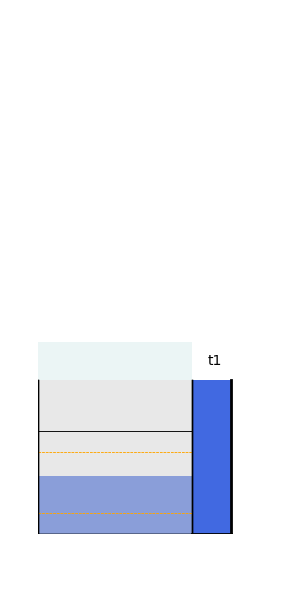

In [ ]:
total_reward = 0
state, _ = myEnv.reset()
for step in range(myEnv.horizon):
    myEnv.render(to_display=False)
    action = agent.sample_action()
    next_state, reward, done, info, _ = myEnv.step(action)
    total_reward += reward
    print()
    print(f'step       = {step}')
    print(f'state      = {state}')
    print(f'action     = {action}')
    print(f'next state = {next_state}')
    print(f'reward     = {reward}')
    state = next_state
    if done:
        break
print(f'episode ended with reward {total_reward}')

myEnv.close()
MovieGen.save_animation(ENV)
Image(open(base_path+ENV+'.gif','rb').read())

## Exercises
We will run through a series of changes to the domain and instance files. The porpuse here is to get familiar with RDDL and observe its power.
In all parts when adding fluents, think carefull on the type (bool/real/etc).

Also note that while you will make many changes to the problem, the important things for the visualizer are not going to change so you are going to be able to keep using the built-in reservoir viz.

### Exercise 1


We will start by only changing the rain. It is now a constant, we will change it to a stochastic rain. For simplicity we will just make is a Bernoulli random variable. Thus, we will either have a constant rain or not.

The Bernoulli distribution in RDDL is declared by using the key word Bernoulli(prob) here prob is the probability for true. As we do not like number in our code do the following, in the domain file:
1. Change the non-fluent RAIN_VAR(reservoir) to be a probabiliy.
2. Change the interm-fluent of the rain accordingly.

In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer


In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 0.5 };  // Constant rainfall
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGHLOW_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  Bernoulli(RAIN_VAR(?r));

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then HIGHLOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### Exercise 2


Now let's make the rain a little more interesting.
Change the Bernoulli random variable for the rain to Normal.
use the previously defined RAIN_VAR fluent for the variance and set the mean to zero. You can change the value of RAIN_VAR if you would like to play with the width of the rain gaussian.

**Important:** Negative numbers can be sampled from Normal distribution, we do not want negative rain, how will you fix that?


In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer

In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 4.0 };  // Constant rainfall
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGHLOW_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  max[0, Normal(0,RAIN_VAR(?r))];

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then HIGHLOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### Exercise 3


Now we will add the evaporation.
We will need to do the following:
1. Add a non-fluent EVAPORATION_FACTOR (same for all reservoirs), representing the fraction of the water from the tank the will be evaporeted. Set the value to be 0.05.
2. Add an interm-fluent for (pvariable and cpf) evaporated(reservoir), which calculates how much water are going to be evaporated at the current time step.
3. Substract the new evaporated interm fluent from the state.


In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer


In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 4.0 };  // Constant rainfall
        EVAPORATION_FACTOR: { non-fluent, real, default = 0.05 };   // Maximum fraction of evaporation
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGHLOW_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        evaporated(reservoir): {interm-fluent, real}; // Evaporated water from reservoir
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  max[0, Normal(0,RAIN_VAR(?r))];

        // amount of evaporated water, proportional to the amount of water in the tank
        evaporated(?r) = EVAPORATION_FACTOR * rlevel(?r) / TOP_RES(?r);

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - evaporated(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then HIGHLOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGHLOW_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### Exercise 4


Let's play a little with the reward function.
Currently the penalty for violating the max and min level is the same. Let's seperate them.
1. Change the name of HIGHLOW_COST to HIGH_COST.
2. Add another nonfluent LOW_COST with different default value than HIGH_COST.
3. Update the reward function with the new non-fluents.


In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer

In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 4.0 };  // Constant rainfall
        EVAPORATION_FACTOR: { non-fluent, real, default = 0.05 };   // Maximum fraction of evaporation
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGH_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        LOW_COST(reservoir) : { non-fluent, real, default =  -6.0 }; // Penalty per unit of level > MAX_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        evaporated(reservoir): {interm-fluent, real}; // Evaporated water from reservoir
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  max[0, Normal(0,RAIN_VAR(?r))];

        // amount of evaporated water, proportional to the amount of water in the tank
        evaporated(?r) = EVAPORATION_FACTOR * rlevel(?r) / TOP_RES(?r);

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - evaporated(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then LOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### Exercise 5


Now we don't want it to rain all the time.
We will going to define a new state-fluent is_raining(reservoir).
It has to be a state because it needs to remember a previous value!

1. Define the fluent for the new state.
2. Define a new non-fluent IS_RAIN_PROB(reservoir)
3. Define the cpf for the new state. The state will flip its current state based on Bernoulli sampling with IS_RAIN_PROB.
4. update the rain(reservoir) interm-fluent cpf with the new definition, such that if it is not raining rain=0 else rain is the same amount as before (the Normal distribution).


In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer

In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir):  { non-fluent, real, default = 4.0 };  // Constant rainfall
        IS_RAIN_PROB(reservoir): { non-fluent, real, default = 0.2 };  // rainfall switching prob
        EVAPORATION_FACTOR: { non-fluent, real, default = 0.05 };   // Maximum fraction of evaporation
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGH_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        LOW_COST(reservoir) : { non-fluent, real, default =  -6.0 }; // Penalty per unit of level > MAX_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        evaporated(reservoir): {interm-fluent, real}; // Evaporated water from reservoir
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level
        is_raining(reservoir) : {state-fluent, bool, default = false }; // is raining

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  is_raining(?r) * max[0, Normal(0,RAIN_VAR(?r))];

        // amount of evaporated water, proportional to the amount of water in the tank
        evaporated(?r) = EVAPORATION_FACTOR * rlevel(?r) / TOP_RES(?r);

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        is_raining'(?r) = Bernoulli(IS_RAIN_PROB(?r));

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - evaporated(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then LOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

### Exercise 6


We are going to make it a little more complicated.
The rain season should not just flip, it should do round-robin amoung the 4 seasons.

For that we will give only the general guidelines.
1. We need now a season(reservoir) state variable, that can obtain 4 values only! hint: enum.
2. The cpf of the new state can be a Bernoulli switching probability like before, but now it should go to the next season based on the current one, e.g., spring comes after winter.
3. Each season should be associated with _different_ amount of rain. one way to achieve this is to define a RAIN_VAR for each season, where in the winter it is higher than in the spring or fall, and zero in the summer (we assume here sane climate :) Another option is to define the season as an arugment for the IS_RAIN_PROB non fluent.

Define all the fluents and cpfs.

Note: the name RAIN_VAR is critical for the visualizer (even if you wont use it), do not change the name of this non-fluent.

In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_DOMAIN = """

#########################
# write your domain here
#########################

"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

#### Answer

In [ ]:
RESERVOIR_DOMAIN = """
domain reservoir_control_cont {

	requirements = {
		concurrent,           // different reservoirs are controlled independently
		reward-deterministic, // this domain does not use a stochastic reward
		intermediate-nodes,   // this domain uses intermediate pvariable nodes
		constrained-state     // this domain uses state constraints
	};

	types {
		reservoir: object;

    season : {@Summer, @Fall, @Winter, @Spring};
	};

    pvariables {

		// Constants
        TOP_RES(reservoir): { non-fluent, real, default = 100.0 }; // Overflowing amount
        MAX_LEVEL(reservoir): { non-fluent, real, default = 80.0 };  // The upper bound for desired reservoir level
        MIN_LEVEL(reservoir): { non-fluent, real, default = 20.0 };  // The lower bound for desired reservoir level
        RAIN_VAR(reservoir, season):  { non-fluent, real, default = 1.0 };  // rainfall prob
        SEASON_SWITCH_PROB(reservoir): { non-fluent, real, default = 0.2}; // season switch prob
        EVAPORATION_FACTOR: { non-fluent, real, default = 0.05 };   // Maximum fraction of evaporation
        RES_CONNECT(reservoir, reservoir): { non-fluent, bool, default = false }; // Indicates 2nd reservoir is forward connected to 1st reservoir
        CONNECTED_TO_SEA(reservoir): {non-fluent, bool, default = false}; // reservoirs connected to the sea

        HIGH_COST(reservoir) : { non-fluent, real, default =  -5.0 }; // Penalty per unit of level < MIN_LEVEL
        LOW_COST(reservoir) : { non-fluent, real, default =  -6.0 }; // Penalty per unit of level > MAX_LEVEL
        OVERFLOW_COST(reservoir): { non-fluent, real, default = -15.0 }; // Penalty per unit of level > TOP_RES

        // Intermediate fluents
        rain(reservoir):   {interm-fluent, real}; // Amount of rain fell
        overflow(reservoir):   {interm-fluent, real}; // Excess overflow (over the rim)
        evaporated(reservoir): {interm-fluent, real}; // Evaporated water from reservoir
        inflow(reservoir):     {interm-fluent, real}; // Amount received from backward reservoirs
        individual_outflow(reservoir): {interm-fluent, real}; // Net amount of water released from reservoir to individually connected reservoirs
        released_water(reservoir): {interm-fluent, real}; // Actual amount of water released (with action clipping

        // State fluents
        rlevel(reservoir): {state-fluent, real, default = 50.0 }; // Reservoir level
        current_season(reservoir): {state-fluent, season, default = @Summer }; // current season for rainfall

        // Action fluents
        release(reservoir): { action-fluent, real, default = 0.0 }; // Action to set outflow of reservoir
    };

    cpfs {
        // amount of ran fall for this timestep
        rain(?r) =  max[0, Normal(0,RAIN_VAR(?r, current_season(?r)))];

        // amount of evaporated water, proportional to the amount of water in the tank
        evaporated(?r) = EVAPORATION_FACTOR * rlevel(?r) / TOP_RES(?r);

        // feasible bound enforcement on action
        released_water(?r) = max[0, min[rlevel(?r), release(?r)]];

        // amount of water spilled over the rim
        overflow(?r) = max[0, rlevel(?r) - released_water(?r) - TOP_RES(?r)];

        // the fraction of outflow to each of the forward connected tanks
        individual_outflow(?r) = released_water(?r)* 1 / ((sum_{?out: reservoir} [RES_CONNECT(?r,?out)]) + CONNECTED_TO_SEA(?r));

        // total incoming flow from all previous connected tanks
        inflow(?r) = (sum_{?in : reservoir} [RES_CONNECT(?in,?r) * individual_outflow(?in)]);

        current_season'(?r) = if (Bernoulli(SEASON_SWITCH_PROB(?r)))
                             then (switch(current_season(?r)){
                                      case @Summer    :   @Fall,
                                      case @Fall      :   @Winter,
                                      case @Winter    :   @Spring,
                                      case @Spring    :   @Summer
                                  })
                              else current_season(?r);

        rlevel'(?r) = min[TOP_RES(?r), max[0, rlevel(?r) + inflow(?r) + rain(?r) - evaporated(?r) - overflow(?r) - released_water(?r)]];
    };

    reward = (sum_{?r: reservoir} [if ((rlevel'(?r) >= MIN_LEVEL(?r)) ^ (rlevel'(?r) <= MAX_LEVEL(?r)))
                                   then 0
                                   else if (rlevel'(?r) <= MIN_LEVEL(?r))
                                        then LOW_COST(?r) * (MIN_LEVEL(?r) - rlevel'(?r))
                                        else if ((rlevel'(?r) > MAX_LEVEL(?r)) ^ (rlevel'(?r) <= TOP_RES(?r)))
                                             then HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r))
                                             else HIGH_COST(?r) * (rlevel'(?r) - MAX_LEVEL(?r)) + OVERFLOW_COST(?r) * overflow(?r)
                                   ]);


    action-preconditions {
		forall_{?r : reservoir} release(?r) <= TOP_RES(?r);
		forall_{?r : reservoir} release(?r) >= 0;
	};

	state-invariants {

		forall_{?r : reservoir} rlevel(?r) >= 0;
		forall_{?r : reservoir} rlevel(?r) <= TOP_RES(?r);
        (sum_{?r : reservoir} [CONNECTED_TO_SEA(?r)]) == 1;
	};

}
"""
domain_file = open(base_path+'domain.rddl','w')
domain_file.write(RESERVOIR_DOMAIN)
domain_file.close()

In [ ]:
RESERVOIR_INSTANCE = """
non-fluents Reservoir_1nf {
	domain = reservoir_control_dis;

	objects{
		reservoir: {t1};
	};

	non-fluents {
		CONNECTED_TO_SEA(t1);
    RAIN_VAR(t1, @Summer) = 0;
    RAIN_VAR(t1, @Spring) = 0.3;
    RAIN_VAR(t1, @Fall) = 0.5;
	};
}

instance Reservoir_cont_single {
	domain = reservoir_control_cont;
	non-fluents = Reservoir_1nf;

	init-state{
		rlevel(t1) = 45.0;
	};

	max-nondef-actions = pos-inf;
	horizon = 120;
	discount = 1.0;
}
"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

### Exercise 7


So far we played with the dynamics of the problem.
Let's see how easy it is to define larger problems.

We now have a single reservoir problem (look at the instance file).
Here we will define a 3 reservoir environment.
There will be no code copy!

1. At the instance file in the non-fluents block, add two more reservoir objects t1 and t2.
2. Connect the 3 reservoirs in a line topology, i.e., t1 should be connected to t2, t2 should be connected to t3 and t3 should be connected to the sea.
You manipulate this in the non-fluents part of the non-fluents block of the instance file. Use the RES_CONNECT(reservoir, reservoir) non-fluent to define the topology.

In the following code block write the updated instance file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_INSTANCE = """

#########################
# write your domain here
#########################

"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

#### Answer

In [ ]:
RESERVOIR_INSTANCE = """
non-fluents Reservoir_1nf {
	domain = reservoir_control_dis;

	objects{
		reservoir: {t1, t2, t3};
	};

	non-fluents {
    RES_CONNECT(t1,t2);
    RES_CONNECT(t2,t3);
		CONNECTED_TO_SEA(t3);
    RAIN_VAR(t1, @Summer) = 0;
    RAIN_VAR(t1, @Spring) = 0.3;
    RAIN_VAR(t1, @Fall) = 0.5;
    RAIN_VAR(t2, @Summer) = 0;
    RAIN_VAR(t2, @Spring) = 0.3;
    RAIN_VAR(t2, @Fall) = 0.5;
    RAIN_VAR(t3, @Summer) = 0;
    RAIN_VAR(t3, @Spring) = 0.3;
    RAIN_VAR(t3, @Fall) = 0.5;
	};
}

instance Reservoir_cont_single {
	domain = reservoir_control_cont;
	non-fluents = Reservoir_1nf;

	init-state{
		rlevel(t1) = 45.0;
	};

	max-nondef-actions = pos-inf;
	horizon = 120;
	discount = 1.0;
}
"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

### Exercise 8


Now we are just going to change the topology of the reservoirs.
Still 3, but now in a triangle topology:
1 **and** 2 should be connected to 3, and 3 should be connected to the sea.

In the following code block write the updated domain file, run it an re-run the interaction loop:

In [ ]:
RESERVOIR_INSTANCE = """

#########################
# write your domain here
#########################

"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

#### Answer

In [ ]:
RESERVOIR_INSTANCE = """
non-fluents Reservoir_1nf {
	domain = reservoir_control_dis;

	objects{
		reservoir: {t1, t2, t3};
	};

	non-fluents {
    RES_CONNECT(t1,t3);
    RES_CONNECT(t2,t3);
		CONNECTED_TO_SEA(t3);
    RAIN_VAR(t1, @Summer) = 0;
    RAIN_VAR(t1, @Spring) = 0.3;
    RAIN_VAR(t1, @Fall) = 0.5;
    RAIN_VAR(t2, @Summer) = 0;
    RAIN_VAR(t2, @Spring) = 0.3;
    RAIN_VAR(t2, @Fall) = 0.5;
    RAIN_VAR(t3, @Summer) = 0;
    RAIN_VAR(t3, @Spring) = 0.3;
    RAIN_VAR(t3, @Fall) = 0.5;
	};
}

instance Reservoir_cont_single {
	domain = reservoir_control_cont;
	non-fluents = Reservoir_1nf;

	init-state{
		rlevel(t1) = 45.0;
	};

	max-nondef-actions = pos-inf;
	horizon = 120;
	discount = 1.0;
}
"""
instance_file = open(base_path+'instance.rddl','w')
instance_file.write(RESERVOIR_INSTANCE)
instance_file.close()

# __Part 3__: Multi Reservoir Control - Model-based Solution

In this part we will look at a multi reservoir problem as focus on how to solve it using JaxPlanner.

## Prerequisites

In order to use JaxPlanner, first we need to install it.

In [ ]:
!pip install pyRDDLGym-jax

## Imports

In [43]:
from pyRDDLGym_jax.core.planner import (
    load_config, JaxStraightLinePlan, JaxBackpropPlanner, JaxOfflineController
)
from rddlrepository.core.manager import RDDLRepoManager
from IPython.display import Image # for displaying gifs in colab

## Prerequisites

JaxPlanner is initialized using the JaxConfigManager procedure.
The input for the procedure is a config file which we will go over, and the output (the important parameters at least) are the planner, the optimization arguments from the config, an environment with Jax back-end.

### Config file



The config file includes all the relevant informaiton the planner needs.
It has 3 parts.

Model:
```
[Compiler]
method='DefaultJaxRDDLCompilerWithGrad'
sigmoid_weight=20
```
Optimizer:
```
[Planner]
method='JaxStraightLinePlan'
method_kwargs={}
optimizer='rmsprop'
optimizer_kwargs={'learning_rate': 0.1}
batch_size_train=32
batch_size_test=32
```

and Optimization:
```
[Optimize]
key=42
epochs=3000
train_seconds=20
```

Now let us create a config file for JaxPlanner.

First, please choose for how many seconds you would like the optimize the planner.

In [73]:
Time = 60 # @param {type: "integer"}
Gif = "output_JAX" # @param {type: "string"}

In [74]:
RESERVOIR_CONFIG = """
[Compiler]
method='DefaultJaxRDDLCompilerWithGrad'
sigmoid_weight=20

[Planner]
method='JaxStraightLinePlan'
method_kwargs={}
optimizer='rmsprop'
optimizer_kwargs={'learning_rate': 0.1}
batch_size_train=32
batch_size_test=32

[Optimize]
key=42
epochs=3000
train_seconds=%d
""" % Time
config_file = open(base_path+'Reservoir.cfg','w')
config_file.write(RESERVOIR_CONFIG)
config_file.close()

## Initializating the Planner

Using the config file we can now initialize the planner.

The planner needs to know the environment model, which he will compile into a computation graph, and the optimization arguments.

The load_config method basically parses the configuration file into a dictionary, which in turn is passed to the planner.

In this example we will use the reservoir domain with the built in instance 1 - 10 connected reservoirs.

In [79]:
base_path = '/content/'
ENV = 'Reservoir_Continuous'

config = base_path + 'Reservoir.cfg'
planner_args, plan_args, train_args = load_config(config)

myEnv = pyRDDLGym.make(ENV,1, vectorized=True)
MovieGen = MovieGenerator(base_path, ENV, 200)

manager = RDDLRepoManager()
ProblemInfo = manager.get_problem(ENV)
myEnv.set_visualizer(ProblemInfo.get_visualizer(), movie_gen=MovieGen, movie_per_episode=True)

## Optimizing the planner

Here we give an any time optimization procedure.
The planner is comprised of two parts. The first is the actual planner JaxRDDLBackpropPlanner, and the second is a wraper which use the planner. The wrapper is actually an agent, which optimizes the planner and samples actions from it.

There are two agents, the first is JaxOfflineController, which produces an open loop offline plan. This is the basic agent which we will demonstrate here. There is another type of agent which is called JaxOnlinePlanner, and this one is an MPC like agent.

In [ ]:
# create the planning algorithm
planner = JaxBackpropPlanner(rddl=myEnv.model, **planner_args)
controller = JaxOfflineController(planner, **train_args)

From here on, we use the Jax agent as any other agent with the standard interactive loop.

Note: we have optimized a StraightLine plan, i.e., not a feedback policy, which means the actions are mapped to time steps and not as response to the current state.

In [ ]:
total_reward = 0
state, _ = myEnv.reset()
for step in range(myEnv.horizon):
    myEnv.render(to_display=False)
    action = controller.sample_action(state)
    next_state, reward, done, info, _ = myEnv.step(action)
    total_reward += reward
    print()
    print(f'step       = {step}')
    print(f'state      = {state}')
    print(f'action     = {action}')
    print(f'next state = {next_state}')
    print(f'reward     = {reward}')
    state = next_state
    if done:
        break
print(f'episode ended with reward {total_reward}')

myEnv.close()
MovieGen.save_animation(Gif)
Image(open(base_path+Gif+'.gif','rb').read())

Now, let's try to optimize a policy. We call these Deep Reactive Policies, or just policies :)

To do policy optimization with JaxPlan, we need to change the configuration file.

Under the `[Planner]` section:

1. Replace the method line with:
`method='JaxDeepReactivePolicy'`

2. Replace the arguments line with:
`method_kwargs={'topology': [128, 128]}`

3. Now run the optimization process again, note that you will need to give it a little more time, as initilization of a NN policy takes a little longer.
